In [98]:
import numpy as np
from scipy import stats
from helper import models
from scipy.special import erfcinv
import pandas as pd
from matplotlib import pyplot as plt
import os

In [99]:
def icd_method(c_null, conc, time, depth, shift = True):
    try:
        ### Determine concentration-front position at each time
        t_front = np.sqrt(time)
        x_front = []
        cs_exp = np.nanmean(conc[:, 0])

        for i in range(conc.shape[0]):
            profile = conc[i, :]
            idx = np.where(np.diff(np.sign(profile - c_null)))[0]

            if len(idx) > 0:
                j = idx[0]

                # look at two surrounding rows
                c1, c2 = profile[j], profile[j + 1]
                x1, x2 = depth[j], depth[j + 1]

                # linear interpolation
                x = x1 + (c_null - c1) * (x2 - x1) / (c2 - c1)

                x_front.append(x)
            
            else:
                x_front.append(np.nan)

        x_front = np.array(x_front)

        valid_front = np.isfinite(x_front) & np.isfinite(t_front)

        t_front_valid = t_front[valid_front]
        x_front_valid = x_front[valid_front]

        # Fit x_front vs sqrt(time)
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            t_front_valid, x_front_valid)

        # Calculate D from slope
        d_front = (slope / (2 * erfcinv(c_null / cs_exp))) ** 2

        # Confidence intervals
        n = len(x_front_valid)
        df = n - 2
        t_val = stats.t.ppf(0.975, df)
        marg_of_err = t_val * std_err
        slope_lower = slope - marg_of_err
        slope_upper = slope + marg_of_err

        lb = (slope_lower / (2 * erfcinv(c_null / cs_exp))) ** 2
        ub = (slope_upper / (2 * erfcinv(c_null / cs_exp))) ** 2

        # Restrict profile comparison to x > x0 if requested
        start_idx = np.searchsorted(depth, intercept, side = "right") if shift else 0

        depth_fit = depth[start_idx:]
        conc_fit = conc[:, start_idx:]

        # Geerate model concentration profiles
        sim_conc = np.zeros_like(conc_fit)

        for i, ti in enumerate(time):
            if ti == 0:
                sim_conc[i, :] = models.semi_infinite(
                    depth_fit,
                    intercept,
                    d_front,
                    cs_exp,
                    0.001
                )
            else:
                sim_conc[i, :] = models.semi_infinite(
                    depth_fit,
                    intercept,
                    d_front,
                    cs_exp,
                    ti
                )

        # Calculate residuals and r2
        mask = np.isfinite(conc_fit) & np.isfinite(sim_conc)
        
        residuals = conc_fit[mask] - sim_conc[mask]

        n_profile = residuals.size
        p = 2 # D and x0 fitted

        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((conc_fit[mask] - np.nanmean(conc_fit[mask]))**2)

        rse = np.sqrt(ss_res / (n_profile - p))

        r2_profile = 1 - ss_res / ss_tot

        # store results
        out = {
            "c_null"        : c_null,
            "t_0.5"         : t_front,
            "iso_front"     : x_front,
            "r2_front"      : r_value ** 2,
            "slope"         : slope,
            "ci_slope"      : (slope_lower, slope_upper),
            "d"             : d_front,
            "ci_d"          : (lb, ub),
            "intercept"     : intercept,
            "rse"           : rse,
            "r2_profile"    : r2_profile,
            "start_idx"     : start_idx
        }
        return out
    
    except Exception as e:
        print(f"Error :{e}")

In [100]:
dir = r"\\svm_uhn\Coolens_Research\Isaac\Experiments\pcl2201_paper"

In [101]:
filetypes = ["conc_xt", "x", "t"]
tracers = ["vis", "gad", "au03", "au61", "au57"]

names = {"vis": ["vis_12", "vis_15", "vis_20"],
         "gad": ["gad_4", "gad_6", "gad_2"],
         "au03": ["au03_3"],
         "au61": ["au61_1", "au61_2"],
         "au57": ["au57_1", "au57_2"]}

cnulls = {"vis": [5, 10, 20, 30],
         "gad": [5, 10, 20, 25],
         "au03": [0.5, 1, 2, 3],
         "au61": [1, 2, 3, 4, 5],
         "au57": [0.2, 0.5, 1, 1.3]}

In [ ]:
all_result = {} # for storing all results

# Visipaque

In [103]:
vis_names = names["vis"]
vis_dat = {name: {type: np.load(os.path.join(dir, name+"_"+type+".npy")) 
                  for type in filetypes} for name in vis_names}

In [104]:
vis_null = cnulls["vis"] # Cnull
vis_result = {name: {c_null: icd_method(c_null, 
                                        vis_dat[name]["conc_xt"], 
                                        vis_dat[name]["t"],
                                        vis_dat[name]["x"]) for c_null in vis_null}
                                        for name in vis_names}
all_result["vis"] = vis_result

# Gadovist

In [105]:
gad_names = names["gad"]
gad_dat = {name: {type: np.load(os.path.join(dir, name+"_"+type+".npy")) 
                  for type in filetypes} for name in gad_names}

In [106]:
gad_null = cnulls["gad"]
gad_result = {name: {c_null: icd_method(c_null, 
                                        gad_dat[name]["conc_xt"], 
                                        gad_dat[name]["t"],
                                        gad_dat[name]["x"]) for c_null in gad_null}
                                        for name in gad_names}
all_result["gad"] = gad_result

# Au13-0003

In [107]:
au03_names = names["au03"]
au03_dat = {name: {type: np.load(os.path.join(dir, name+"_"+type+".npy")) 
                  for type in filetypes} for name in au03_names}

In [108]:
au03_null = cnulls["au03"]
au03_result = {name: {c_null: icd_method(c_null, 
                                        au03_dat[name]["conc_xt"], 
                                        au03_dat[name]["t"],
                                        au03_dat[name]["x"]) for c_null in au03_null}
                                        for name in au03_names}
all_result["au03"] = au03_result

# Au13-0061

In [109]:
au61_names = names["au61"]
au61_dat = {name: {type: np.load(os.path.join(dir, name+"_"+type+".npy")) 
                  for type in filetypes} for name in au61_names}

In [110]:
au61_null = cnulls["au61"]
au61_result = {name: {c_null: icd_method(c_null, 
                                        au61_dat[name]["conc_xt"], 
                                        au61_dat[name]["t"],
                                        au61_dat[name]["x"]) for c_null in au61_null}
                                        for name in au61_names}
all_result["au61"] = au61_result

# Au13-0057

In [111]:
au57_names = names["au57"]
au57_dat = {name: {type: np.load(os.path.join(dir, name+"_"+type+".npy")) 
                  for type in filetypes} for name in au57_names}

In [112]:
au57_null = cnulls["au57"]
au57_result = {name: {c_null: icd_method(c_null, 
                                        au57_dat[name]["conc_xt"], 
                                        au57_dat[name]["t"],
                                        au57_dat[name]["x"]) for c_null in au57_null}
                                        for name in au57_names}
all_result["au57"] = au57_result

# Process data

In [123]:
d_all = []
rows = []
for tracer in tracers:
    r = all_result[tracer]
    d_list = [r[name][cnull]["d"]for name, cnull in zip(names[tracer], cnulls[tracer])]
    d_med = np.nanmedian(d_list)
    d_iqr = (np.quantile(d_list, 0.25), np.quantile(d_list, 0.75))
    n = len(r.keys())

    row = {
        "tracer": tracer,
        "median d": d_med,
        "iqr d": d_iqr,
        "n": n
    }

    rows.append(row)
    d_all.append(d_list)

In [122]:
out_df = pd.DataFrame(rows)
out_df

,tracer,median d,iqr d,n
0,vis,0.000147,"(0.00013307725733028195, 0.00015706316288310464)",3
1,gad,0.000356,"(0.000310605889177051, 0.0003634315763706075)",3
2,au03,0.000281,"(0.0002805301842415831, 0.0002805301842415831)",1
3,au61,0.000647,"(0.0005735211189352835, 0.0007214394203507806)",2
4,au57,0.000134,"(0.00011560153010441655, 0.00015301676879984715)",2


In [129]:
names.keys()

dict_keys(['vis', 'gad', 'au03', 'au61', 'au57'])

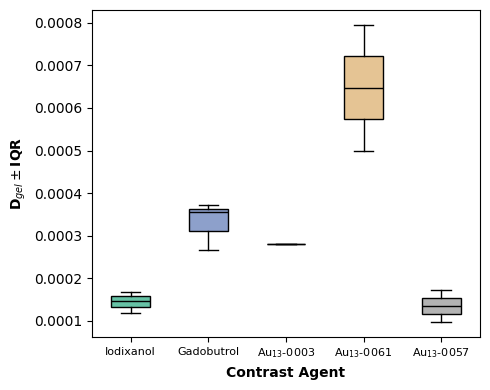

In [160]:
labels = ["Iodixanol", "Gadobutrol", f"Au$_{{13}}$-0003", f"Au$_{{13}}$-0061", f"Au$_{{13}}$-0057"]
colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

fig, ax = plt.subplots(figsize = (5, 4))
bplot = ax.boxplot(d_all, patch_artist = True)
ax.set_xticklabels(labels,
                   fontdict = {"size": 8})
ax.set_ylabel(f"D$_{{gel}} \\pm $IQR", fontdict = {"weight": "bold"})
ax.set_xlabel("Contrast Agent", fontdict = {"weight": "bold"})

for patch, color in zip(bplot["boxes"], colors):
    patch.set_facecolor(color)

for median in bplot["medians"]:
    median.set_color("black")

plt.tight_layout()
plt.savefig(r"\\svm_uhn\Coolens_Research\Isaac\Experiments\pcl2201_paper\figures\dgel_all.png", dpi = 400)
plt.show()

<Figure size 640x480 with 0 Axes>